In [1]:
# Combine Time-Dependence and SimpleDiff

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sympy import *
import matplotlib.pyplot as plt
init_printing(use_latex=true)
filename = "TestDataLots.xlsx"

In [2]:
# Establish symbols
n, T, k, i, j, t, lda, lda2 = symbols('n T k i j t \lambda \lambda_2')       
# n wells & T timepoints
# k = highest degree of w polynomial

In [3]:
# Choose highest degree of polynomial
k = 3

In [4]:
# Establish number of wells
n = pd.read_excel(filename, sheet_name='n').iloc[0,0]
n

5

In [5]:
# Establish number of timepoints
T = pd.read_excel(filename, sheet_name='T').iloc[0,0]
T

41

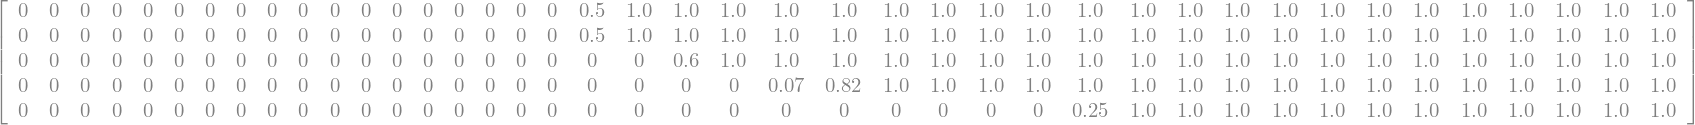

In [6]:
# Establish binary matrix for wells being on or off
z = MatrixSymbol('z', n, T)      # Row 0 = well 0   , Column 3 = Timepoint 3
#pprint(z.as_explicit())
zReal = Matrix(pd.read_excel(filename, sheet_name="OnOff").to_numpy().T)
zReal

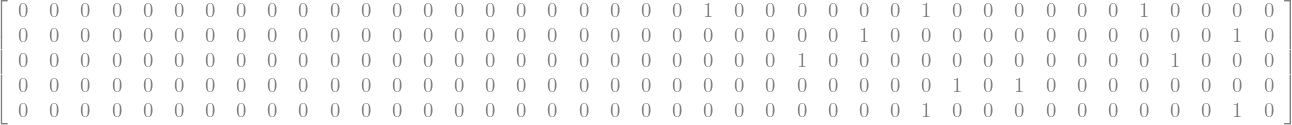

In [7]:
# Establish binary matrix for wells being measured or not
d = MatrixSymbol('d', n, T)      # Row 0 = well 0   , Column 3 = Timepoint 3
#pprint(d.as_explicit())
dReal = Matrix(pd.read_excel(filename, sheet_name="Measured").to_numpy().T)
dTotal = sum(dReal)
dReal

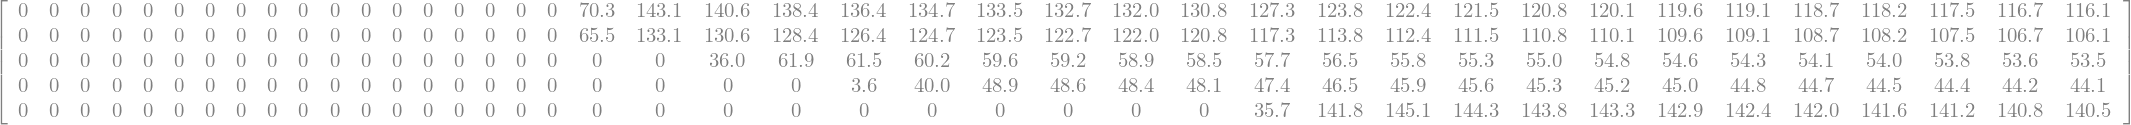

In [8]:
# Establish matrix of actual mass flows
m = MatrixSymbol('m', n, T)  
#pprint(m.as_explicit())
mReal = Matrix(pd.read_excel(filename, sheet_name="MassFlows").to_numpy().T)
mReal

In [9]:
# Establish matrix / vector of total mass flow
M = MatrixSymbol('M', 1, T)
#pprint(M.as_explicit())
MReal = Matrix(pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T)
MReal

In [10]:
# Set w as an expression based on t
wMat = MatrixSymbol('w', n, k+1)
pprint(wMat.as_explicit())

⎡w₀₀  w₀₁  w₀₂  w₀₃⎤
⎢                  ⎥
⎢w₁₀  w₁₁  w₁₂  w₁₃⎥
⎢                  ⎥
⎢w₂₀  w₂₁  w₂₂  w₂₃⎥
⎢                  ⎥
⎢w₃₀  w₃₁  w₃₂  w₃₃⎥
⎢                  ⎥
⎣w₄₀  w₄₁  w₄₂  w₄₃⎦


In [11]:
# Instantaneous value of wi is wMati * [1, t, t^2, t^3 etc]
tList = []
for power in range(k+1):
    tList.append(t**power)
ts = Matrix(tList)
wInstant = Matrix([wMat[i,:].as_explicit().dot(ts) for i in range(n)])
wInstant[0,0]

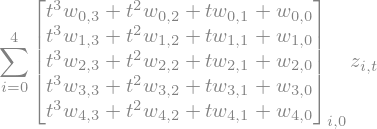

In [12]:
Sum(z[i, t]*wInstant[i, 0], (i, 0, n-1))

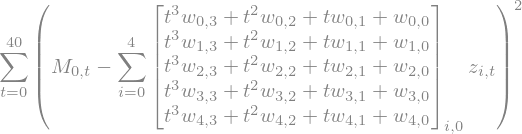

In [13]:
S1 = Sum((M[0,t] - Sum(z[i, t]*wInstant[i,0], (i, 0, n-1)))**2 , (t, 0, T-1))
S1

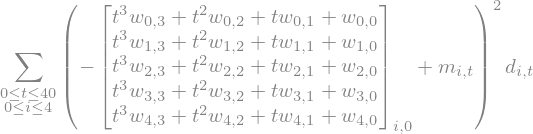

In [14]:
S2 = Sum(Sum(d[i,t]*((m[i,t]-wInstant[i,0]))**2 , (t, 0, T-1)), (i, 0, n-1))
S2

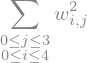

In [15]:
Ridge = Sum(Sum(wMat[i,j]**2 , (j, 0, k)), (i, 0, n-1))
Ridge

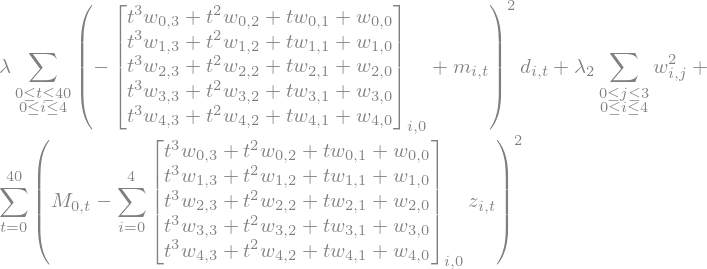

In [16]:
I = S1 + lda*S2 + lda2*Ridge
I

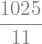

In [17]:
optLda = T*n**2/dTotal
optLda

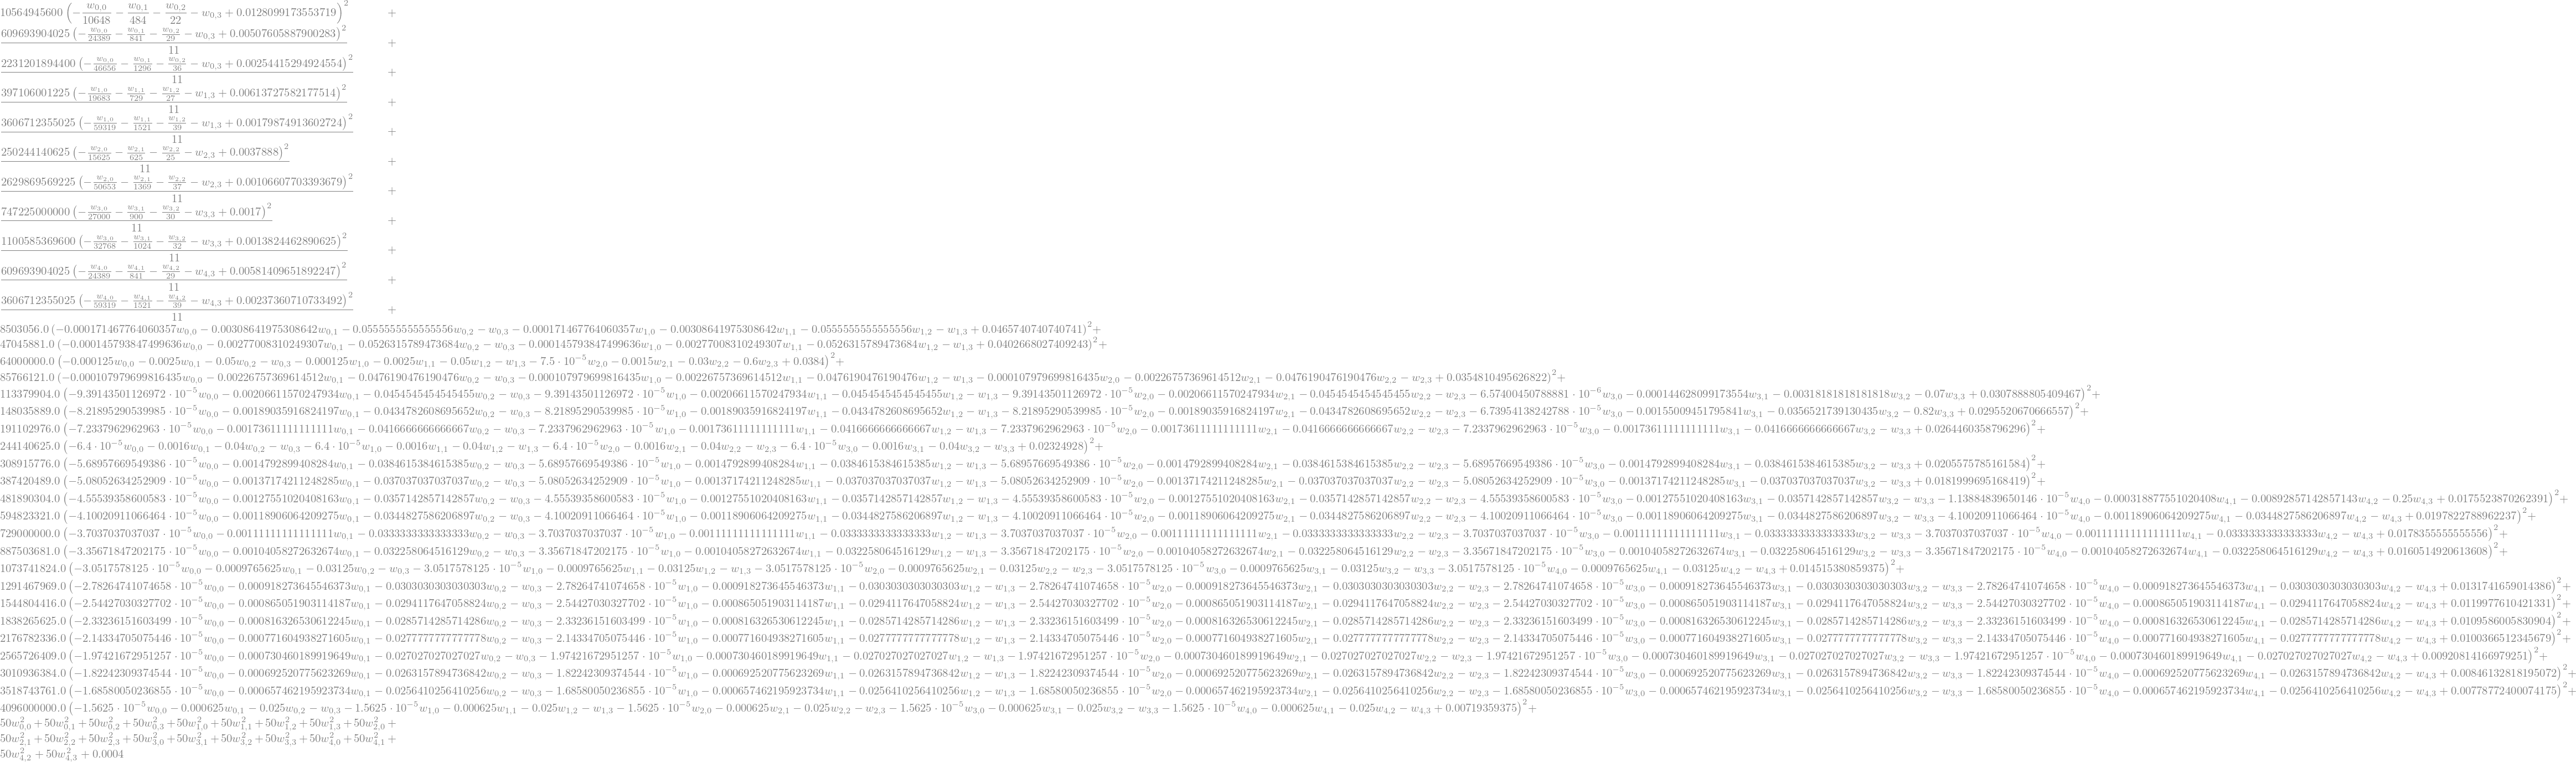

In [18]:
lda2value = 50
Inac = I.subs({M: MReal, z: zReal, d: dReal, m: mReal, lda: optLda, lda2: lda2value}).doit()
Inac

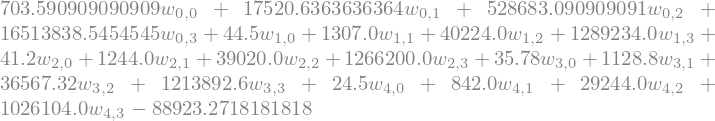

In [19]:
Inac.diff(wMat[0,0])

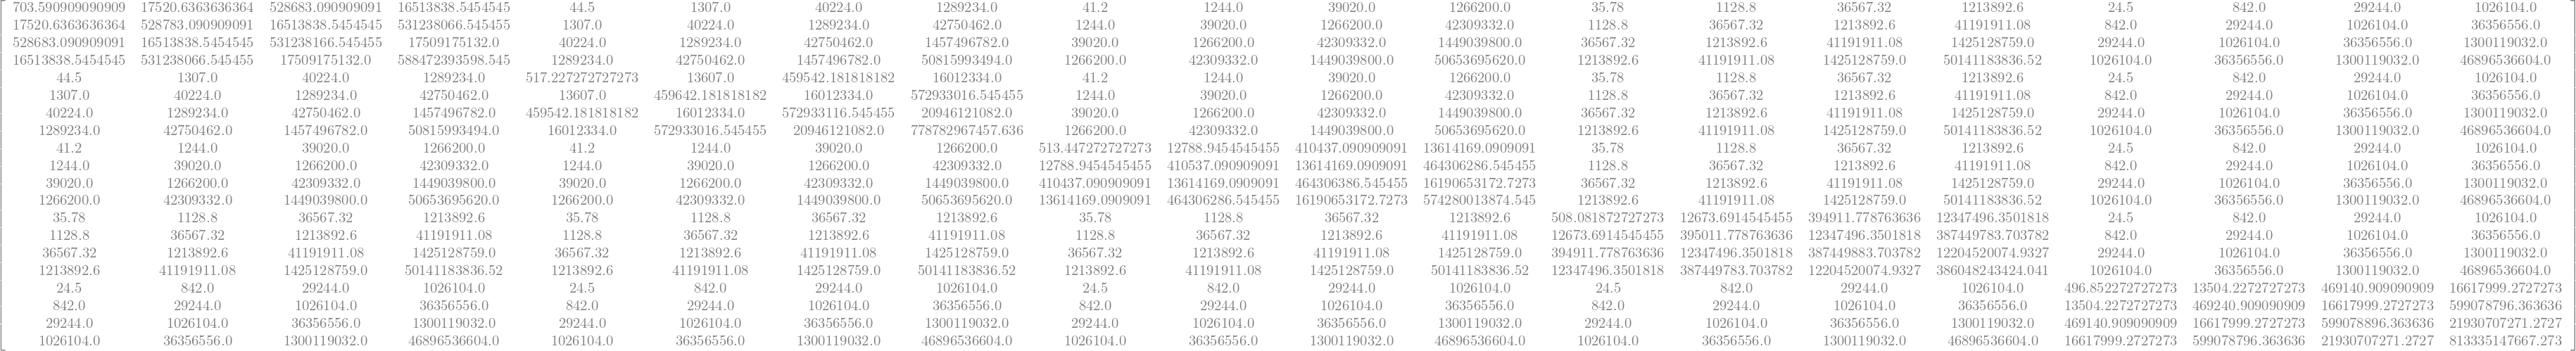

In [20]:
DiffA = np.zeros([(k+1)*n,(k+1)*n])
Diffb = np.zeros((k+1)*n)
# Fill in matrix with values for Aw=b  
for i in range(n):
    for j in range(k+1):
        # v = vertical index
        v = i*(k+1)+j
        dwij = Poly(Inac.diff(wMat[i,j]).doit())
        Diffb[v] = -1*dwij.coeffs()[-1]
        for i2 in range(n):
            for j2 in range(k+1):
                # h = horizontal index
                h = i2*(k+1)+j2
                #print(v, h)
                DiffA[v,h] = dwij.coeff_monomial(wMat[i2, j2])
                
    
# Then solve for w
DiffMatrixA = Matrix(DiffA)
DiffMatrixb = Matrix(Diffb)
DiffMatrixA

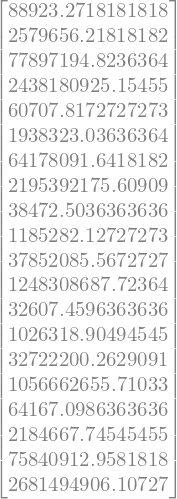

In [21]:
DiffMatrixb

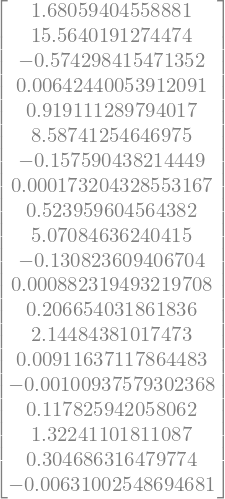

In [22]:
results = DiffMatrixA.inv()*DiffMatrixb
results

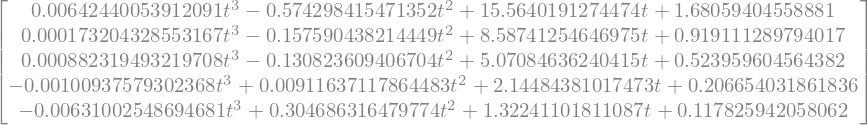

In [23]:
wExpr = results.reshape(n, k+1)*ts
wExpr

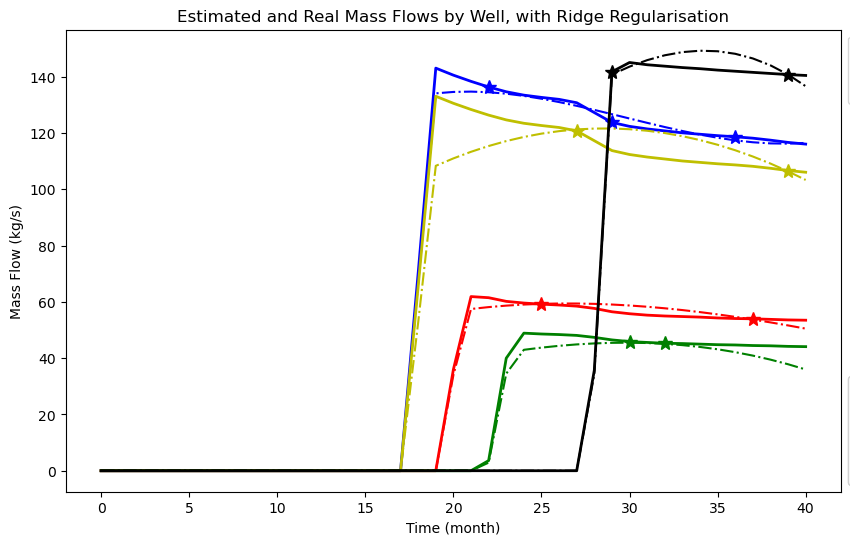

In [24]:
# Plot results from all wells
plt.figure(figsize=(10,6))
colours=['b', 'y', 'r', 'g', 'k']
lines=[]
for i in range(n):
    l1, = plt.plot(range(T),mReal[i,:][:], colours[i]+'-', lw=2, label="Real flow for well "+str(i))
    # Plot Time-Dependently
    toplot = []
    for time in range(T):
        resplot = wExpr[i].subs(t, time)
        toplot.append(resplot*zReal[i,time])
        #print(time, toplot)
    l2, = plt.plot(range(T),toplot, colours[i]+'-.', lw=1.5, label="Estimated flow for well "+str(i))
    # Plot TFT points
    monthplot = []
    tftplot = []
    for month,element in enumerate(dReal[i,:]):
        if element==1:
            monthplot.append(month)
            tftplot.append(mReal[i,month])
    l3, = plt.plot(monthplot, tftplot, colours[i]+'*', markersize=10, label="TFT measurements for well "+str(i))
    lines.append([l1,l2,l3])
    
plt.title("Estimated and Real Mass Flows by Well, with Ridge Regularisation")
plt.xlabel("Time (month)")
plt.ylabel("Mass Flow (kg/s)")

legend1 = plt.legend(lines[0], ["True Data", "Model Estimate", "TFT Point Provided"], bbox_to_anchor=(1., 1.0), loc='upper left')
legend2 = plt.legend([l[0] for l in lines], ["Well 1", "Well 2", "Well 3", "Well 4", "Well 5"], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.gca().add_artist(legend1)
plt.gca().add_artist(legend2)
plt.rcParams['font.size'] = 15

plt.savefig("Ridge.svg", bbox_inches='tight', pad_inches=4)


0 [0, 0, 0, 0, 0]
1 [0, 0, 0, 0, 0]
2 [0, 0, 0, 0, 0]
3 [0, 0, 0, 0, 0]
4 [0, 0, 0, 0, 0]
5 [0, 0, 0, 0, 0]
6 [0, 0, 0, 0, 0]
7 [0, 0, 0, 0, 0]
8 [0, 0, 0, 0, 0]
9 [0, 0, 0, 0, 0]
10 [0, 0, 0, 0, 0]
11 [0, 0, 0, 0, 0]
12 [0, 0, 0, 0, 0]
13 [0, 0, 0, 0, 0]
14 [0, 0, 0, 0, 0]
15 [0, 0, 0, 0, 0]
16 [0, 0, 0, 0, 0]
17 [0, 0, 0, 0, 0]
18 [66.6136778355389, 52.7216813944451, 0, 0, 0]
19 [134.140192779762, 108.377809966849, 0, 0, 0]
20 [134.636814718964, 111.016821561835, 34.0019994214341, 0, 0]
21 [134.755767891917, 113.361436799818, 57.4896822934028, 0, 0]
22 [134.535598701857, 115.412694906770, 58.1588905884144, 2.87403956434378, 0]
23 [134.014853552019, 117.171635108661, 58.6829178377176, 34.5052283314451, 0]
24 [133.232078845636, 118.639296631465, 59.0670579582717, 42.9803243121955, 0]
25 [132.225820985944, 119.816718701151, 59.3166048670361, 43.7539845068882, 0]
26 [131.034626376177, 120.704940543691, 59.4368524809700, 44.3944710749846, 0]
27 [129.697041419571, 121.305001385056, 59.4330

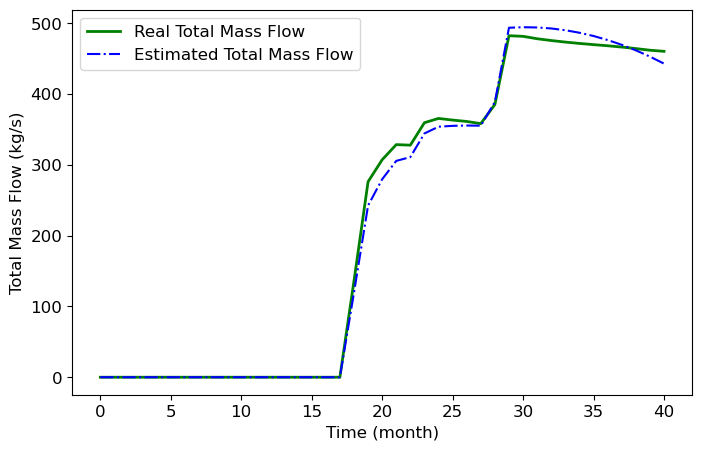

In [25]:
# # Plot total flow vs found total flow
# totalFlowFound = np.zeros((T,1))
# times = range(T)
# for time in range(T):
#     tff = [wExpr[i].subs(t, time)*zReal[i,time] for i in range(n)]
#     #print(t, tff)
#     totalFlowFound[time] = sum(tff)

# plt.plot(list(Matrix(times).T), list(MReal), 'g-', lw=2, label="Real Total Mass Flow")
# plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Estimated Total Mass Flow")

# plt.title("Estimated and real total mass flows over time")
# plt.xlabel("Time (month)")
# plt.ylabel("Total Mass Flow (kg/s)")
# plt.legend()

# Plot total flow vs found total flow
plt.figure(figsize=(8,5))
plt.rcParams['font.size'] = 12
totalFlowFound = np.zeros((T,1))
times = range(T)
for t2 in range(T):
    tff = [wExpr[i].subs(t, t2)*zReal[i,t2] for i in range(n)]
    print(t2, tff)
    totalFlowFound[t2] = sum(tff)

plt.plot(list(Matrix(times).T), list(MReal), 'g-', lw=2, label="Real Total Mass Flow")
plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Estimated Total Mass Flow")


#plt.title("Estimated and real total mass flows over time")
plt.xlabel("Time (month)")
plt.ylabel("Total Mass Flow (kg/s)")
plt.legend()
plt.savefig("CubicRidgeB.svg", bbox_inches='tight')

In [26]:
# Calculate average out of sample squared error (MSE). Then sqrt
SE = 0
for i in range(n):
    for t2 in range(T):
        real = mReal[i, t2]
        estimated = zReal[i,t2]*wExpr[i].subs(t, t2)
        #print(estimated)
        RSS = (real - estimated)**2
        SE = SE + RSS

MSE = SE / n / T
RMSE = sqrt(MSE)
RMSE

In [ ]:
Bayesian model based on normal distribution of provided data. Bishop book

SyntaxError: invalid syntax (937307824.py, line 1)